In [1]:
import matplotlib.pyplot as plt
from torch.profiler import profile, ProfilerActivity
from cubes import get_cube
from utils import profile_and_capture_cpu, profile_and_capture_gpu

In [2]:
device = "cuda"
order = "1"
results = {}

In [3]:
header_mem = " Peak VRAM" if (device == "cuda") else "  Peak RAM"

print(f"|  N  |     DOFs |     Setup | FWD Solve | BWD Solve | {header_mem} |")
print("| --- | -------- | --------- | --------- | --------- | ---------- |")

for N in [10, 20, 30, 40, 50, 60]:
    cmd = ["python", "cubes.py", "-N", str(N), "-device", device, "-order", order]
    if device == "cuda":
        mem_data, internal_clock = profile_and_capture_gpu(cmd)
    else:
        mem_data, internal_clock = profile_and_capture_cpu(cmd)
    mem_usage = [m for _, m in mem_data]
    setup_t = internal_clock["SETUP_DONE"] - internal_clock["START"]
    fwd_t = internal_clock["FWD_DONE"] - internal_clock["SETUP_DONE"]
    bwd_t = internal_clock["BWD_DONE"] - internal_clock["FWD_DONE"]
    peak_mem_mb = max(mem_usage) if mem_usage else 0.0
    print(
        f"| {N:3d} | {3*N**3:8d} | {setup_t:8.2f}s | {fwd_t:8.2f}s | {bwd_t:8.2f}s "
        f"| {peak_mem_mb:8.1f}MB |"
    )
    results[N] = (mem_data, internal_clock)

|  N  |     DOFs |     Setup | FWD Solve | BWD Solve |  Peak VRAM |
| --- | -------- | --------- | --------- | --------- | ---------- |
|  10 |     3000 |     0.24s |     0.49s |     0.72s |    303.0MB |
|  20 |    24000 |     0.25s |     0.60s |     0.76s |    559.0MB |
|  30 |    81000 |     0.24s |     0.99s |     1.02s |   1509.0MB |
|  40 |   192000 |     0.31s |     1.73s |     1.53s |   3960.0MB |
|  50 |   375000 |     0.42s |     2.94s |     2.35s |   7571.0MB |
|  60 |   648000 |     0.62s |     4.92s |     3.70s |  13079.0MB |


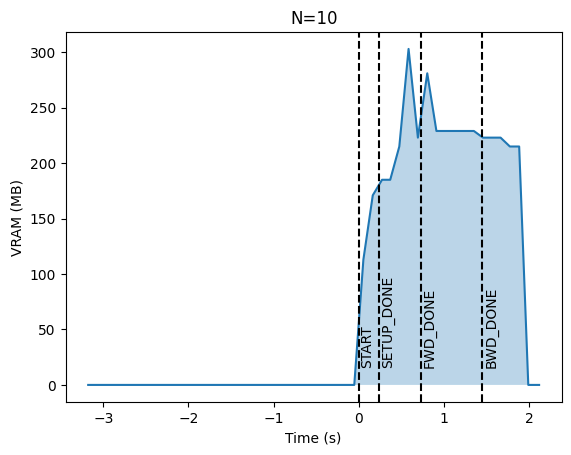

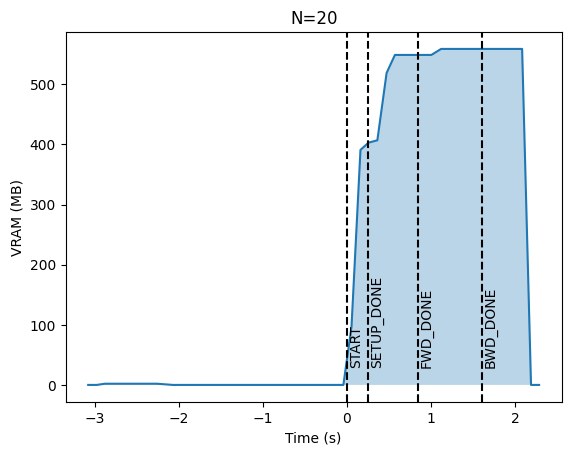

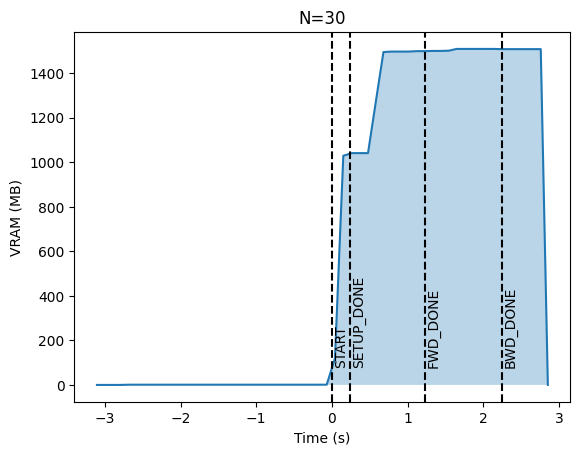

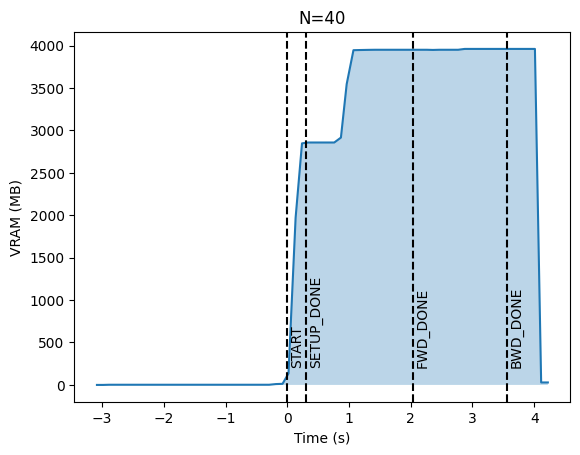

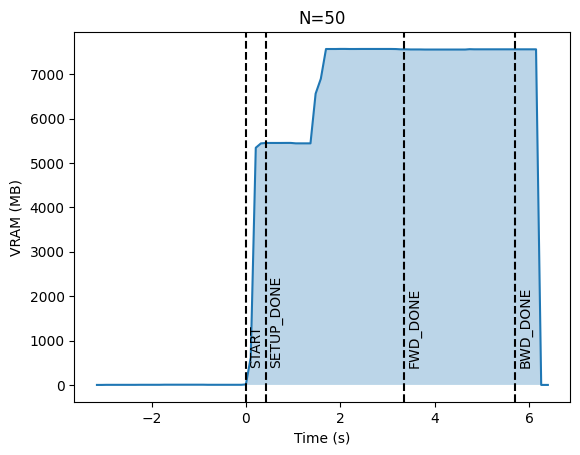

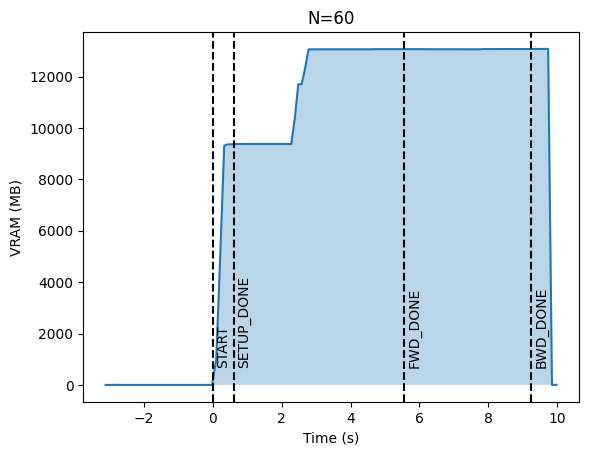

In [4]:
for N, (mem_data, internal_clock) in results.items():
    t0 = internal_clock["START"]
    times = [t - t0 for t, _ in mem_data]
    mem_usage = [m for _, m in mem_data]
    if len(times) == 0:
        continue
    plt.plot(times, mem_usage)
    plt.fill_between(times, mem_usage, alpha=0.3)
    for tag, abs_ts in internal_clock.items():
        if tag not in ["START", "SETUP_DONE", "FWD_DONE", "BWD_DONE"]:
            continue
        relative_ts = abs_ts - t0
        plt.axvline(x=relative_ts, color="black", linestyle="--")
        plt.text(
            relative_ts + 0.01 * max(times),
            0.05 * max(mem_usage),
            tag,
            rotation=90,
            verticalalignment="bottom",
        )
    plt.xlabel("Time (s)")
    plt.ylabel("VRAM (MB)" if device == "cuda" else "RAM (MB)")
    plt.title(f"N={N}")
    plt.show()

In [5]:
import cProfile
import pstats

import torch

torch.set_default_device(device)

def test():
    cube = get_cube(50)
    cube.solve()


cProfile.run("test()", "stats")
p = pstats.Stats("stats")
print(p.sort_stats("time").print_stats(10))

Fri Apr 10 16:02:13 2026    stats

         108383 function calls (107749 primitive calls) in 3.431 seconds

   Ordered by: internal time
   List reduced from 631 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     1940    1.115    0.001    1.960    0.001 c:\Users\meyernil\.conda\envs\torchfem\Lib\site-packages\torch\utils\_device.py:105(__torch_function__)
      745    0.335    0.000    0.337    0.000 {method 'get' of 'cupy._core.core._ndarray_base' objects}
      6/3    0.230    0.038    0.230    0.077 {method 'mean' of 'torch._C.TensorBase' objects}
        1    0.163    0.163    0.163    0.163 {built-in method torch._unique2}
      249    0.155    0.001    0.232    0.001 c:\Users\meyernil\.conda\envs\torchfem\Lib\site-packages\cupyx\scipy\sparse\_dia.py:140(tocsc)
        1    0.139    0.139    0.139    0.139 {built-in method cupy_backends.cuda.libs.cusparse.xcoosortByRow}
        1    0.128    0.128    0.128    0.128 {built-i

In [6]:
with profile(
    activities=[ProfilerActivity.CUDA, ProfilerActivity.CPU],
    profile_memory=True,
    record_shapes=True,
) as prof:
    cube = get_cube(50)
    solution = cube.solve()


# Export trace to Chrome Trace format (this can be opened in chrome://tracing or https://ui.perfetto.dev/)
prof.export_chrome_trace("trace.json")
# Print profiler results
print(prof.key_averages().table(sort_by="cuda_memory_usage", row_limit=10))

c:\Users\meyernil\.conda\envs\torchfem\Lib\site-packages\torch\profiler\profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::empty         0.03%     745.014us         0.06%       1.624ms      10.341us       0.000us         0.00%       0.000us       0.000us       1.09 KB       1.09 KB      11.27 GB      11.27 G